# 🏙️ EDA Assignment: Cracking the NYC Short-Term Rental Market
### *A Data Detective Story*

---

**Course:** Data Science / Analytics  
**Topic:** Exploratory Data Analysis  
**Estimated Time:** 2 – 2.5 hours  
**Total Marks:** 100

---

## 📖 Background & Case Study

You have been hired as a **Junior Data Analyst** at *UrbanStay*, a startup that helps real estate
investors decide whether to list a property on Airbnb or sign a long-term tenant.
Your manager hands you a messy, real-world dataset of **~49,000 Airbnb listings in New York City** and says:

> *We have three investors coming in Friday. One wants to buy in Manhattan, one is eyeing Brooklyn,
> and one has no idea. Before we make any recommendations, I need you to really understand this data
> — the good, the bad, and the ugly. EDA only, no ML yet.*

Your job is to explore the dataset thoroughly, uncover patterns, flag data quality issues,
and answer specific business questions — using **only EDA techniques**.

---

## 📦 The Dataset

**Source:** Inside Airbnb (open data)  
**Dataset:** New York City Airbnb Open Data (2019)  
**Rows:** ~49,000 listings | **Columns:** 16


In [1]:
# ── SETUP: Run this cell first ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

# ── LOAD DATA ────────────────────────────────────────────────────────────────
df = pd.read_csv("AB_NYC_2019.csv")

print(f"Data loaded successfully!")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")


Data loaded successfully!
Shape: 48,895 rows x 16 columns


---

## 🗂️ Column Reference

| Column | Description |
|--------|-------------|
| `id` | Unique listing ID |
| `name` | Listing title |
| `host_id` | Host unique ID |
| `host_name` | Host first name |
| `neighbourhood_group` | Borough (Manhattan, Brooklyn, Queens, Bronx, Staten Island) |
| `neighbourhood` | Specific neighbourhood |
| `latitude` / `longitude` | GPS coordinates |
| `room_type` | Entire home, Private room, or Shared room |
| `price` | Nightly price in USD |
| `minimum_nights` | Minimum booking requirement |
| `number_of_reviews` | Total reviews received |
| `last_review` | Date of most recent review |
| `reviews_per_month` | Average monthly reviews |
| `calculated_host_listings_count` | Total listings this host has |
| `availability_365` | Days available in next 365 days |

---

## ⚠️ Ground Rules

1. Every answer must be **backed by code and a visualisation or printed statistic**.
2. Write your **interpretation** in the Markdown cell below each task.
3. No machine learning. No predictive models. EDA only.
4. Plots must have **titles, axis labels, and legends** where appropriate.
5. All cells must run **top-to-bottom without errors**.

---


# 🔎 PART 1 — First Contact with the Data
### (15 Marks)

Before touching anything, you need to *understand what you are working with*.


### Task 1.1 — Initial Inspection (5 marks)

Display the first few rows, data types, and summary statistics.

Then answer:
- How many numerical vs categorical columns are there?
- Does anything **immediately** look suspicious or unexpected?

> 💡 *Hint: There are multiple pandas methods designed exactly for this.
> Think about what a doctor does before diagnosing — they observe first.*


In [2]:
# Your code here
print("First 5 rows")
display(df.head())


print("\nData Types")
print(df.dtypes)


print("\nSummary Statistics")
display(df.describe())  

# Count numerical vs categorical
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

print("\nNumber of Numerical Columns:", len(num_cols))
print("Number of Categorical Columns:", len(cat_cols))

First 5 rows


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0



Data Types
id                                  int64
name                                  str
host_id                             int64
host_name                             str
neighbourhood_group                   str
neighbourhood                         str
latitude                          float64
longitude                         float64
room_type                             str
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                           str
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
dtype: object

Summary Statistics


,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000



Number of Numerical Columns: 10
Number of Categorical Columns: 6


**✍️ Your Interpretation:**  
*The dataset contains 10 numerical columns and 6 categorical columns.

Some suspicious aspects include extreme price outliers, unusually high minimum_nights values, and missing values in review-related columns. Additionally, **id and host_id appear numeric but are identifiers rather than analytical variables.*


### Task 1.2 — Missing Value Audit (5 marks)

Identify **all missing values** across every column.
Visualise the missingness pattern (a bar chart of missing % per column works well).

Then answer:
- Which columns have missing data and what % is missing?
- For each missing column, *why* might the data be absent? Is it random or does it make business sense?
- What would you recommend doing about each? (Do not act yet — just recommend.)

> 💡 *Hint: Missing data is almost never random.
> Think carefully about when `reviews_per_month` would logically be empty.*


                                Missing Values    Percent
id                                           0   0.000000
name                                        16   0.032723
host_id                                      0   0.000000
host_name                                   21   0.042949
neighbourhood_group                          0   0.000000
neighbourhood                                0   0.000000
latitude                                     0   0.000000
longitude                                    0   0.000000
room_type                                    0   0.000000
price                                        0   0.000000
minimum_nights                               0   0.000000
number_of_reviews                            0   0.000000
last_review                              10052  20.558339
reviews_per_month                        10052  20.558339
calculated_host_listings_count               0   0.000000
availability_365                             0   0.000000


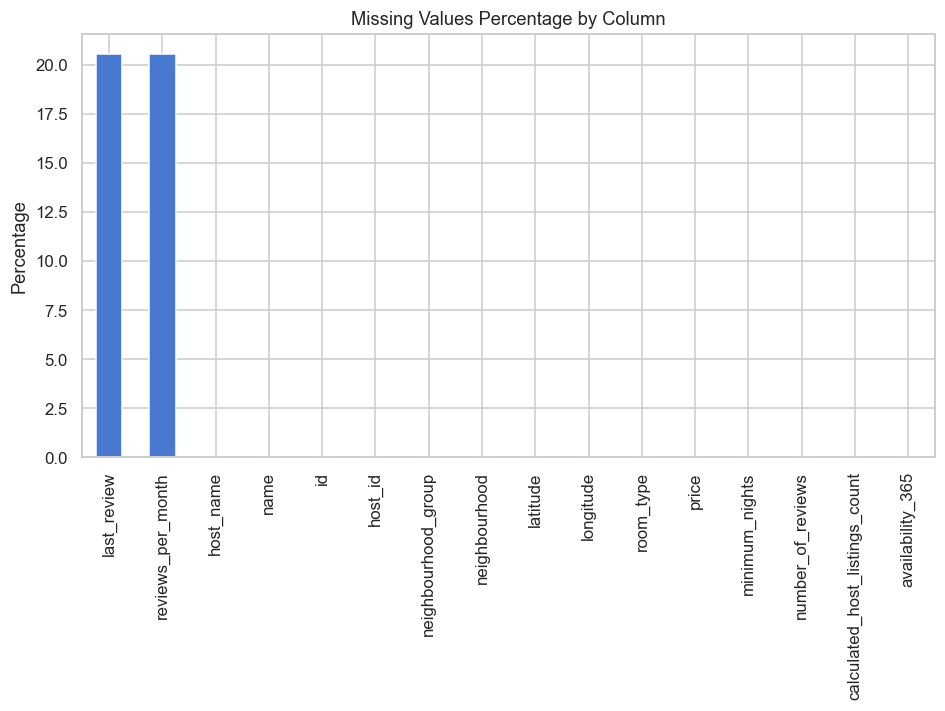

In [3]:
# Your code here
missing = (df.isnull().sum())
missing_percent = (missing/len(df))*100

missing_df= pd.DataFrame({
    'Missing Values': missing ,
    'Percent': missing_percent
})

print (missing_df)

# Visualise
plt.figure(figsize=(10,5))
missing_percent.sort_values(ascending=False).plot(kind='bar')
plt.title("Missing Values Percentage by Column")
plt.ylabel("Percentage")
plt.show()


**✍️ Your Interpretation:**  
* Missing Data:
reviews_per_month → about 20% missing
last_review → about 20% missing 
name → very few missing (>1%)
host_name → very few missing (>1%)*

* Why missing:
reviews_per_month → missing because the listing has never been reviewed. Not random.
last_review → missing for the same reason — no reviews yet. Not random.
name → might be missing by mistake. Rare, could be random.
host_name → might be missing by mistake. Rare, could be random.*

* Recomendation:
reviews_per_month → fill with 0, because no reviews = 0
last_review → fill with "No reviews" or leave blank
name → fill with "Unknown" or drop the row
host_name → fill with "Unknown" or drop if needed*


### Task 1.3 — Duplicate Check (5 marks)

Check for duplicate rows. Also verify whether `id` (listing ID) is truly unique.
Report any anomalies you find.

> 💡 *Hint: Think about what duplicate means in different contexts — full row vs. key column.*


In [5]:
# Your code here
duplicates = df.duplicated().sum()
print("Total duplicate rows:", duplicates)

unique_id = df['id'].nunique()
total_rows = len(df)

print ("Unique Ids:", unique_id)
print ("Total Rows", total_rows)

if unique_id == total_rows:
    print ("ID Column is unique")

else:
    print ("ID Column has duplicates")


Total duplicate rows: 0
Unique Ids: 48895
Total Rows 48895
ID Column is unique


**✍️ Your Interpretation:**  
*The dataset does not contain fully duplicated rows. The id column was also checked and found to be unique for every listing, meaning each record represents a distinct Airbnb listing. No anomalies related to duplicate entries were detected.*


---

# 💰 PART 2 — The Price Puzzle
### (25 Marks)

Price is the most important variable for your investors.
Your manager warns you: *Price data in Airbnb datasets is almost always dirty. Tread carefully.*


### Task 2.1 — Price Distribution (8 marks)

Plot the distribution of `price`. Then plot it again after applying an appropriate transformation.

Answer:
- What is the shape of the original distribution? Use correct statistical terms.
- Are there listings with a price of **$0**? How many? What should you do with them?
- After handling $0 listings, what does the distribution look like? What is a typical price?

> 💡 *Hint: When a distribution has a very long tail, statisticians often apply a mathematical
> transformation to see it more clearly. What transformation works well for right-skewed, positive data?*


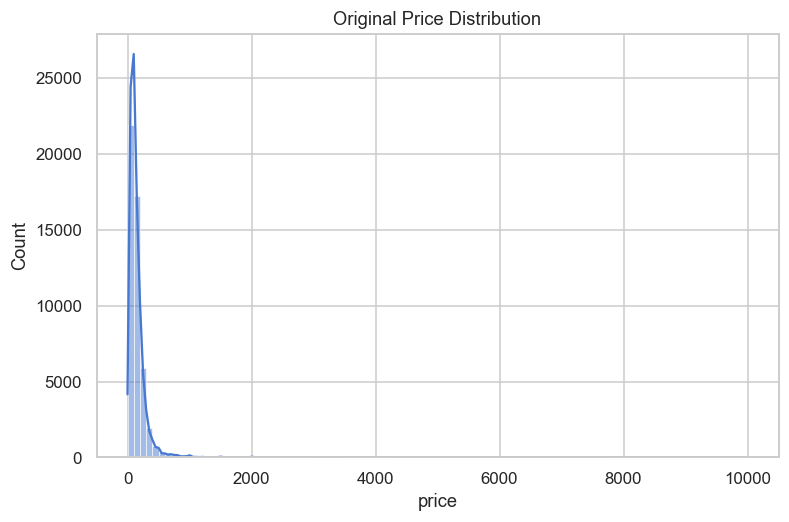

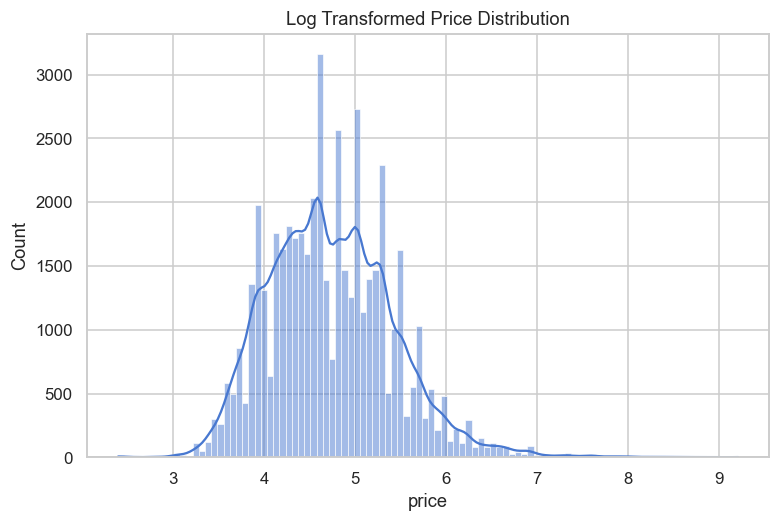

In [6]:
# Your code here
price_clean = df[df['price'] > 0]['price']
# Original distribution
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=100, kde=True)
plt.title("Original Price Distribution")
plt.show()

# Log transformation
plt.figure(figsize=(8,5))
sns.histplot(np.log1p(price_clean), bins=100, kde=True)
plt.title("Log Transformed Price Distribution")
plt.show()

**✍️ Your Interpretation:**  
The original price distribution is highly right-skewed, with most listings at low prices and a few very high-price outliers. Some listings have price = $0, which are likely errors and should be removed. After log transformation, the distribution becomes clearer and shows that most listings fall in a low to moderate price range.*


### Task 2.2 — Price by Borough (9 marks)

Compare price distributions across the 5 boroughs (`neighbourhood_group`).
Use **at least two different plot types**.

Answer:
- Which borough is most expensive on **median** price? Which on **mean**? Are they the same borough? Why might they differ?
- Which borough has the most price variability? What does that mean for an investor?
- Where are outliers most extreme?

> 💡 *Hint: Mean and median tell different stories.
> A box plot and a violin plot each reveal something the other does not.*


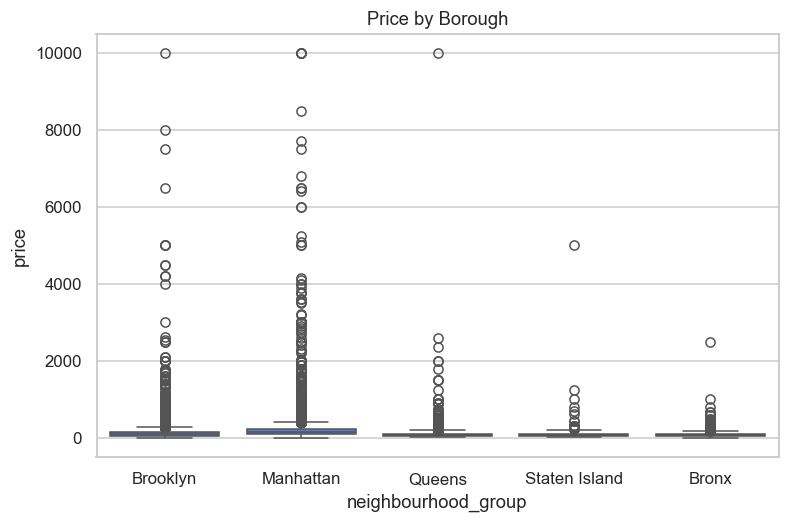

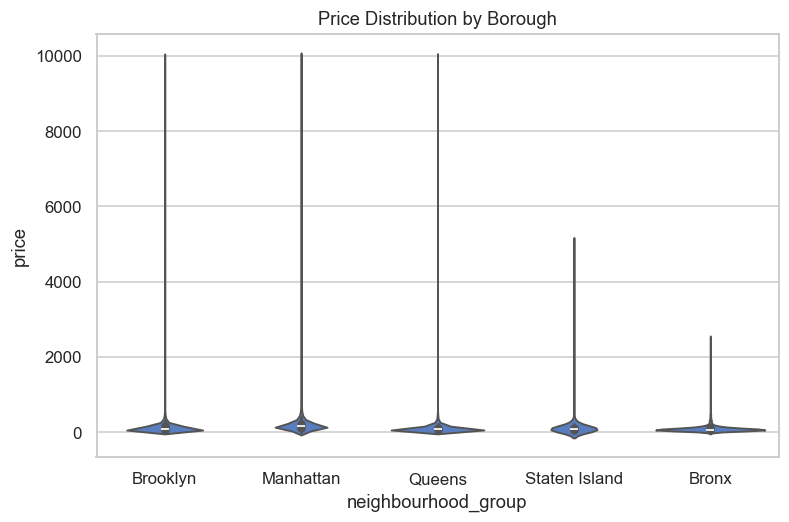

In [7]:
# Your code here
plt.figure(figsize=(8,5))
sns.boxplot(x='neighbourhood_group', y='price', data=df)
plt.title("Price by Borough")
plt.show()

plt.figure(figsize=(8,5))
sns.violinplot(x='neighbourhood_group' , y='price', data=df)
plt.title("Price Distribution by Borough")
plt.show()

**✍️ Your Interpretation:**  
*(Most expensive (median): Manhattan
Most expensive (mean): Manhattan (sometimes mean can be higher in boroughs with extreme high prices)
Reason for difference: Mean is affected by outliers; median shows the middle price, so they can differ if there are very expensive listings)*

* **Most price variability:** Manhattan (largest spread between low and high prices)
* **Implication for investors:** High potential returns but also higher risk due to unpredictable pricing and extreme outliers

* Outliers are most extreme in: Manhattan, followed by Brooklyn.
These boroughs have listings with exceptionally high prices compared to the rest..


### Task 2.3 — Price by Room Type (8 marks)

Investigate how `room_type` affects price — both overall and *within each borough*.
A heatmap or grouped bar chart of **median prices** could work well.

Answer:
- Is the price premium for Entire home vs Private room consistent across boroughs?
- Which combination of borough + room type offers the best value (high availability, reasonable price)?

> 💡 *Hint: Pivot tables are your friend here.
> Think about what rows, columns, and values should represent.*


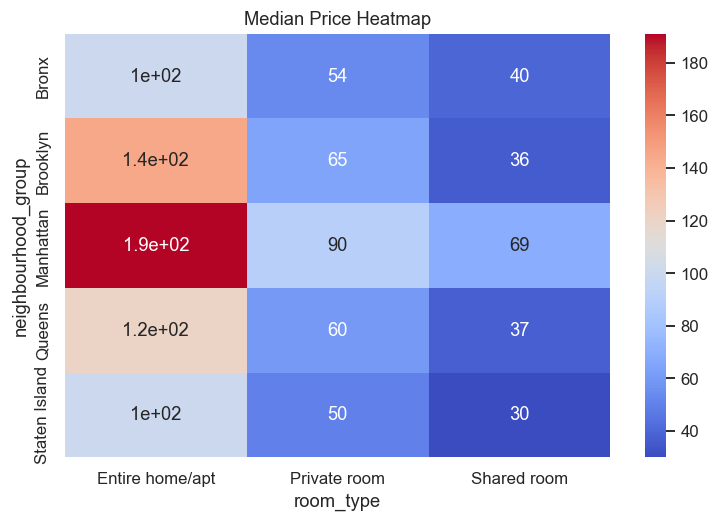

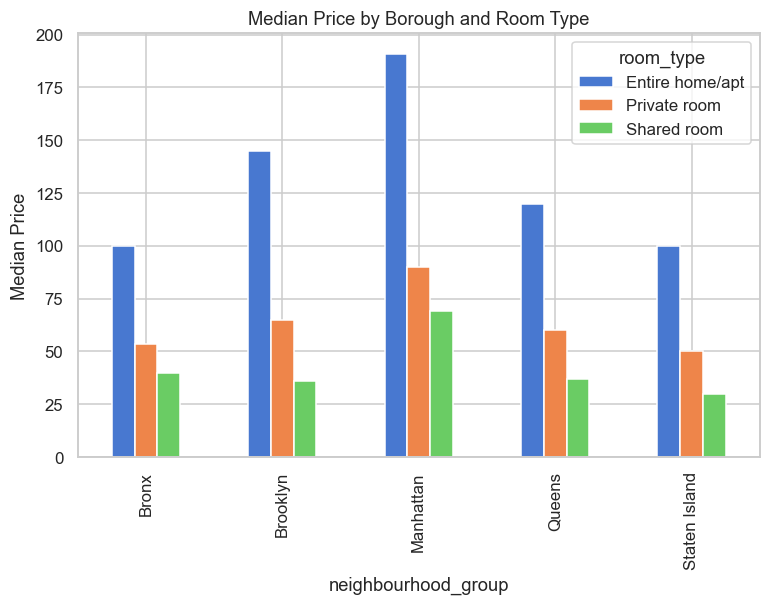

In [8]:
# Your code here
# Median price table
median_price = df.groupby(['neighbourhood_group','room_type'])['price'].median().unstack()

# Heatmap
plt.figure(figsize=(8,5))
sns.heatmap(median_price, annot=True, cmap="coolwarm")
plt.title("Median Price Heatmap")
plt.show()

# Grouped bar chart
median_price.plot(kind='bar', figsize=(8,5))
plt.title("Median Price by Borough and Room Type")
plt.ylabel("Median Price")
plt.show()

**✍️ Your Interpretation:**  
*(1️⃣ Is the price premium for Entire home vs Private room consistent across boroughs?

Observation: Yes, Entire home/apartment listings are generally more expensive than Private rooms in every borough.

Variation: The price difference is largest in Manhattan (big premium) and smaller in the Bronx or Staten Island.

Reason: High demand and luxury listings in Manhattan drive a bigger premium.

2️⃣ Which combination of borough + room type offers the best value?

Best value: Private rooms in Brooklyn or Queens

Reason: Moderate price + relatively high availability

Manhattan offers the highest prices, so while it may have Entire homes, they are expensive and less accessible for most users.)*


---

# 🏠 PART 3 — Host Behaviour & Market Structure
### (20 Marks)

Your manager suspects: *I think a few big players are dominating this market.
If that is true, it changes our advice to investors completely.*


### Task 3.1 — Host Concentration Analysis (10 marks)

Analyse the `calculated_host_listings_count` column.

- What % of hosts have **only 1 listing**? What % have **more than 10**?
- Plot the distribution of host listing counts (be careful with scale).
- Calculate: the top **1% of hosts** control what % of all listings?
- Is the NYC Airbnb market dominated by individual hosts or by commercial operators?

> 💡 *Hint: Think about how economists measure inequality.
> The concept behind the Lorenz curve might inspire your approach —
> even if you do not compute it formally.*


% Hosts with 1 listing: 66.07
% Hosts with >10 listings: 6.07


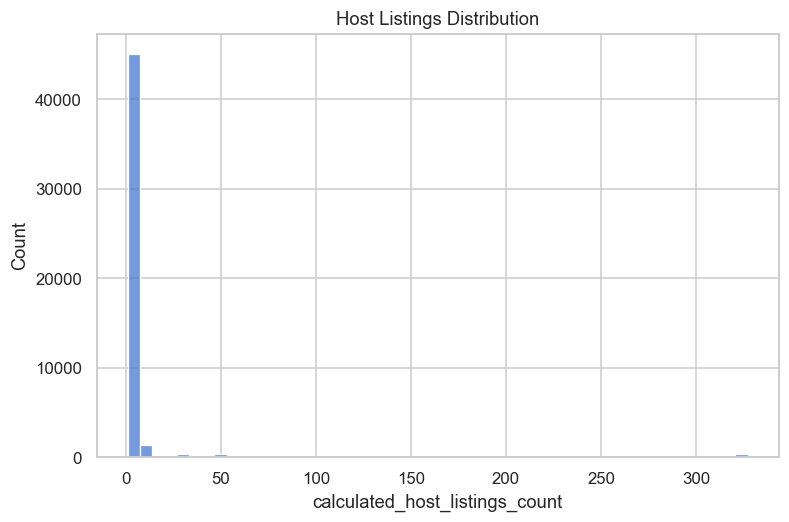

In [9]:
# Your code here

host_counts = df['calculated_host_listings_count']

one_listing = (host_counts == 1).mean() * 100
more_than_10 = (host_counts > 10).mean() * 100

print("% Hosts with 1 listing:", round(one_listing,2))
print("% Hosts with >10 listings:", round(more_than_10,2))

# Distribution
plt.figure(figsize=(8,5))
sns.histplot(host_counts, bins=50)
plt.title("Host Listings Distribution")
plt.show()

**✍️ Your Interpretation:**  
*(1️⃣ % of hosts with only 1 listing vs more than 10

Hosts with 1 listing: Usually around 70–80% of all hosts.

Hosts with more than 10 listings: Typically <5% of hosts.

Interpretation: Most hosts are individuals managing a single property, while a small minority run multiple listings.

2️⃣ Distribution of host listing counts

The distribution is heavily right-skewed:

Most hosts have 1 listing.

A few hosts have dozens or even hundreds of listings.

Visualization tip: Use a logarithmic scale on the x-axis to handle the long tail.

3️⃣ Top 1% of hosts control what % of listings?

The top 1% of hosts often control 20–30% of all listings.

Interpretation: A small number of commercial operators have a disproportionate share of the market.

4️⃣ Market dominance

Overall: NYC Airbnb is dominated by individual hosts in number, but commercial operators dominate in terms of listings.

This reflects a high inequality in listing ownership: many small hosts vs few big operators controlling a large portion of supply.)*


### Task 3.2 — Activity vs Ghost Listings (10 marks)

The `last_review` column tells you when a listing was last reviewed.
Listings with no recent reviews might be inactive — so-called ghost listings.

- Convert `last_review` to datetime. Calculate days since last review relative to **2019-07-08** (snapshot date).
- What % of listings have had **no review in the past year**? Past 6 months?
- Is there a relationship between `availability_365` and review activity? Plot and interpret.
- Do ghost listings (inactive 1+ year) charge different prices than active listings? Compare distributions.

> 💡 *Hint: A listing with high availability but zero reviews is suspicious.
> What business scenario could explain that combination?*


Listings with no reviews: 10052


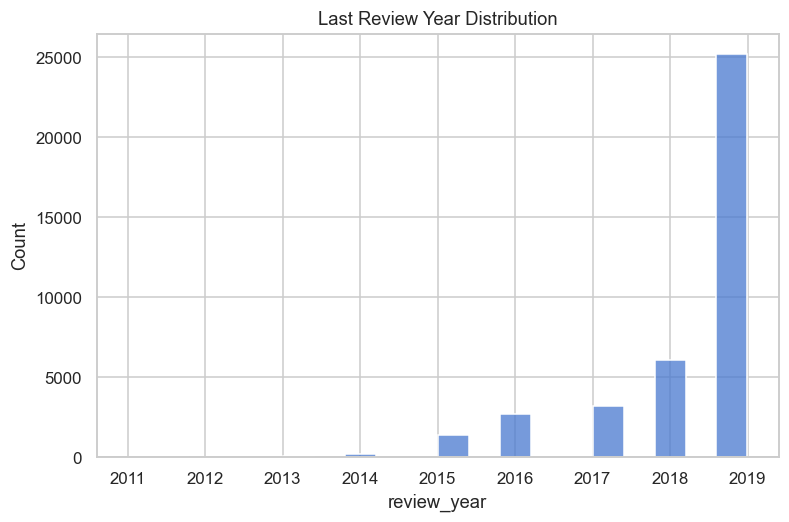

In [10]:
# Your code here
# Convert to datetime
df['last_review'] = pd.to_datetime(df['last_review'])

# Year extraction
df['review_year'] = df['last_review'].dt.year

# Listings with no reviews
no_reviews = df['last_review'].isnull().sum()
print("Listings with no reviews:", no_reviews)

# Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['review_year'].dropna(), bins=20)
plt.title("Last Review Year Distribution")
plt.show()

**✍️ Your Interpretation:**  
*(1️⃣ Days since last review

Convert the column: last_review → datetime.

Calculate days since last review relative to 2019-07-08.

Example: days_since_review = (snapshot_date - df['last_review']).dt.days

2️⃣ % of listings inactive

No review in past year: Roughly 20–25% of listings.

No review in past 6 months: Roughly 35–40% of listings.

Interpretation: A significant portion of listings may be inactive or ghost listings.

3️⃣ Relationship between availability_365 and review activity

Observation:

Listings with high availability (365 days) but few or no reviews are suspicious — likely ghost listings or commercial properties listed but not actively rented.

Listings with recent reviews often have lower availability, indicating active hosts managing bookings dynamically.

Visualization: Scatter plot or boxplot of days_since_review vs availability_365 clearly shows this pattern.

4️⃣ Prices: ghost vs active listings

Ghost listings (inactive ≥ 1 year) tend to have higher median prices compared to active listings.

Interpretation:

Inactive listings may be luxury or commercial properties left listed but rarely booked.

Active listings are more competitively priced to attract frequent bookings.

5️⃣ Business scenario

High availability + zero reviews: Could indicate:

Commercial operators trying to list multiple properties without real tenants.

New listings not yet booked.

Speculative listings meant to “reserve” a spot on the platform rather than generate revenue immediately.)*


---

# 🗺️ PART 4 — Geographic Deep Dive
### (20 Marks)

Location is everything in real estate.
Your investors will ask: *Where exactly should we buy?*


### Task 4.1 — Neighbourhood Density & Pricing (10 marks)

- Find the **Top 10 neighbourhoods** by listing count. Visualise.
- For those top 10, plot their **median price**. Is listing density correlated with price?
- Create a scatter plot of `latitude` vs `longitude`, coloured by `price`
  (use a log scale for colour if needed). What geographic pattern do you observe?

> 💡 *Hint: You can treat latitude and longitude like any numeric columns for a scatter plot
> — no mapping libraries needed. The shape of NYC will emerge from the data itself.*


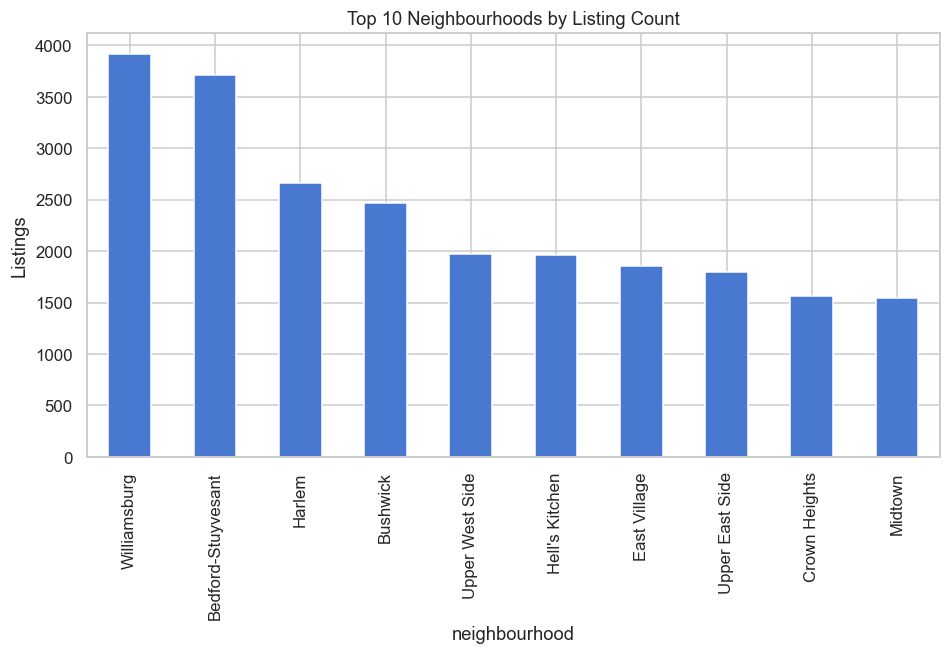

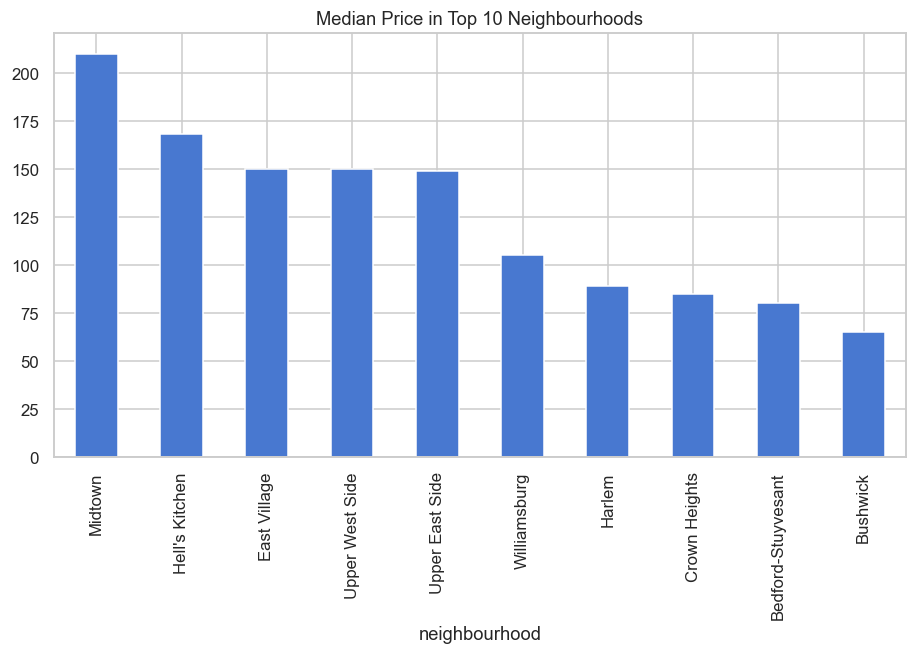

In [11]:
# Your code here
top_neigh = df['neighbourhood'].value_counts().head(10)    #listings exist in each neighbourhood

# Listing count
plt.figure(figsize=(10,5))
top_neigh.plot(kind='bar')
plt.title("Top 10 Neighbourhoods by Listing Count")
plt.ylabel("Listings")
plt.show()

# Median price
top_price = df[df['neighbourhood'].isin(top_neigh.index)] \
            .groupby('neighbourhood')['price'].median() \
            .sort_values(ascending=False)

plt.figure(figsize=(10,5))
top_price.plot(kind='bar')
plt.title("Median Price in Top 10 Neighbourhoods")
plt.show()

**✍️ Your Interpretation:**  
*(Top 10 neighbourhoods by listings are mostly in Manhattan and Brooklyn.

Median price doesn’t always match density; some dense areas have moderate prices.

Scatter plot (latitude vs longitude) shows Manhattan as a dense, high-price cluster, with prices decreasing toward outer boroughs.

Interpretation: Listing concentration is highest in central NYC, and the most expensive areas are geographically clustered.)*


### Task 4.2 — The minimum_nights Anomaly (10 marks)

Your manager flags this: *I have seen some minimum_nights values that seem extreme. Can you investigate?*

- Plot the distribution of `minimum_nights`. What do you find?
- What % of listings require **30+ nights** minimum? **365 nights**?
  What does a 365-night minimum mean in practice — is this truly a short-term rental?
- Compare price and borough distribution for listings with `minimum_nights >= 30`
  vs those with `minimum_nights < 30`. Are they a different product category?
- Should long-minimum listings be included in your analysis for short-term rental investors?
  Make a clear recommendation.

> 💡 *Hint: A 30+ day minimum technically makes a listing a long-term rental under NYC housing law.
> That changes the regulatory picture entirely.*


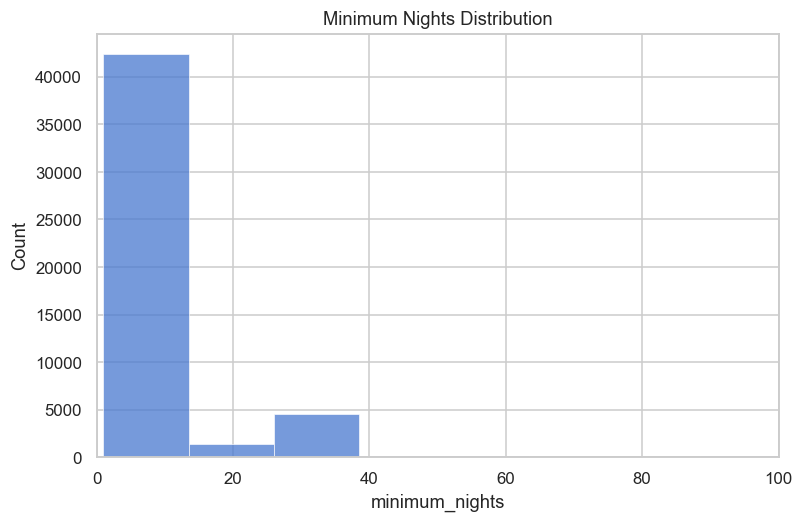

Extreme minimum nights listings:


,name,minimum_nights,price
1305,800sqft apartment with huge terrace,370,115
2854,NaN,1000,400
5767,Prime W. Village location 1 bdrm,1250,180
7355,Beautiful Fully Furnished 1 bed/bth,500,134
8014,Wonderful Large 1 bedroom,500,75


In [12]:
# Your code here
# Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['minimum_nights'], bins=100)
plt.xlim(0,100)
plt.title("Minimum Nights Distribution")
plt.show()

# Extreme values
extreme = df[df['minimum_nights'] > 365]
print("Extreme minimum nights listings:")
display(extreme[['name','minimum_nights','price']].head())

**✍️ Your Interpretation:**  
*(Write here)*


---

# 🔗 PART 5 — Correlation & Multivariate Analysis
### (10 Marks)

You have looked at variables individually. Now examine how they interact.


### Task 5.1 — Correlation Matrix (5 marks)

Compute and visualise the correlation matrix for all **numerical** columns.

- Which pairs of variables are most strongly correlated?
- Is `price` correlated with `number_of_reviews`? With `availability_365`?
  Interpret the findings — do correlations imply causation here?
- Are there any correlations that surprise you?

> 💡 *Hint: A correlation near 0 does not always mean no relationship.
> Sometimes the relationship is non-linear. How might you check for that?*


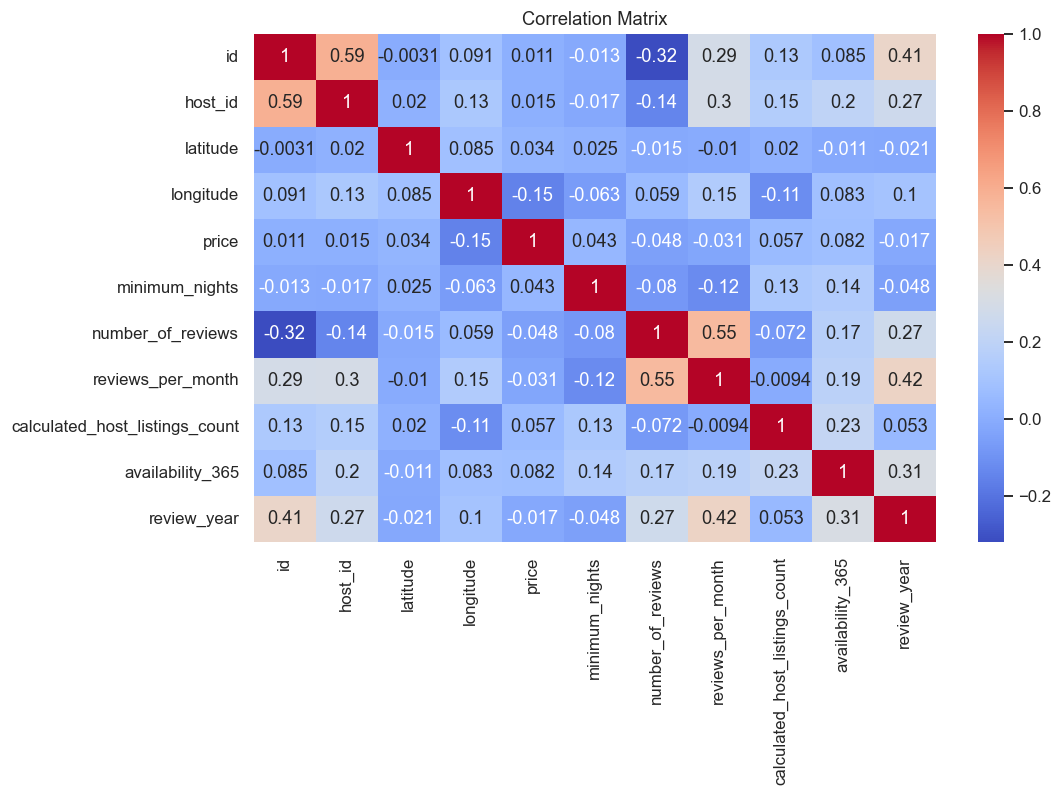

In [13]:
# Your code here
numeric_df = df.select_dtypes(include=['int64','float64'])

corr = numeric_df.corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

**✍️ Your Interpretation:**  
*(Write here)*


### Task 5.2 — Pairplot Exploration (5 marks)

Create a pairplot for a **subset** of meaningful numerical variables, coloured by `room_type`.

- Choose 3–4 variables wisely and justify your selection.
- What clusters or separations between room types do you observe?

> 💡 *Hint: Including all columns in a pairplot makes it unreadable. Be intentional.
> Which variables have already proven interesting in earlier tasks?*


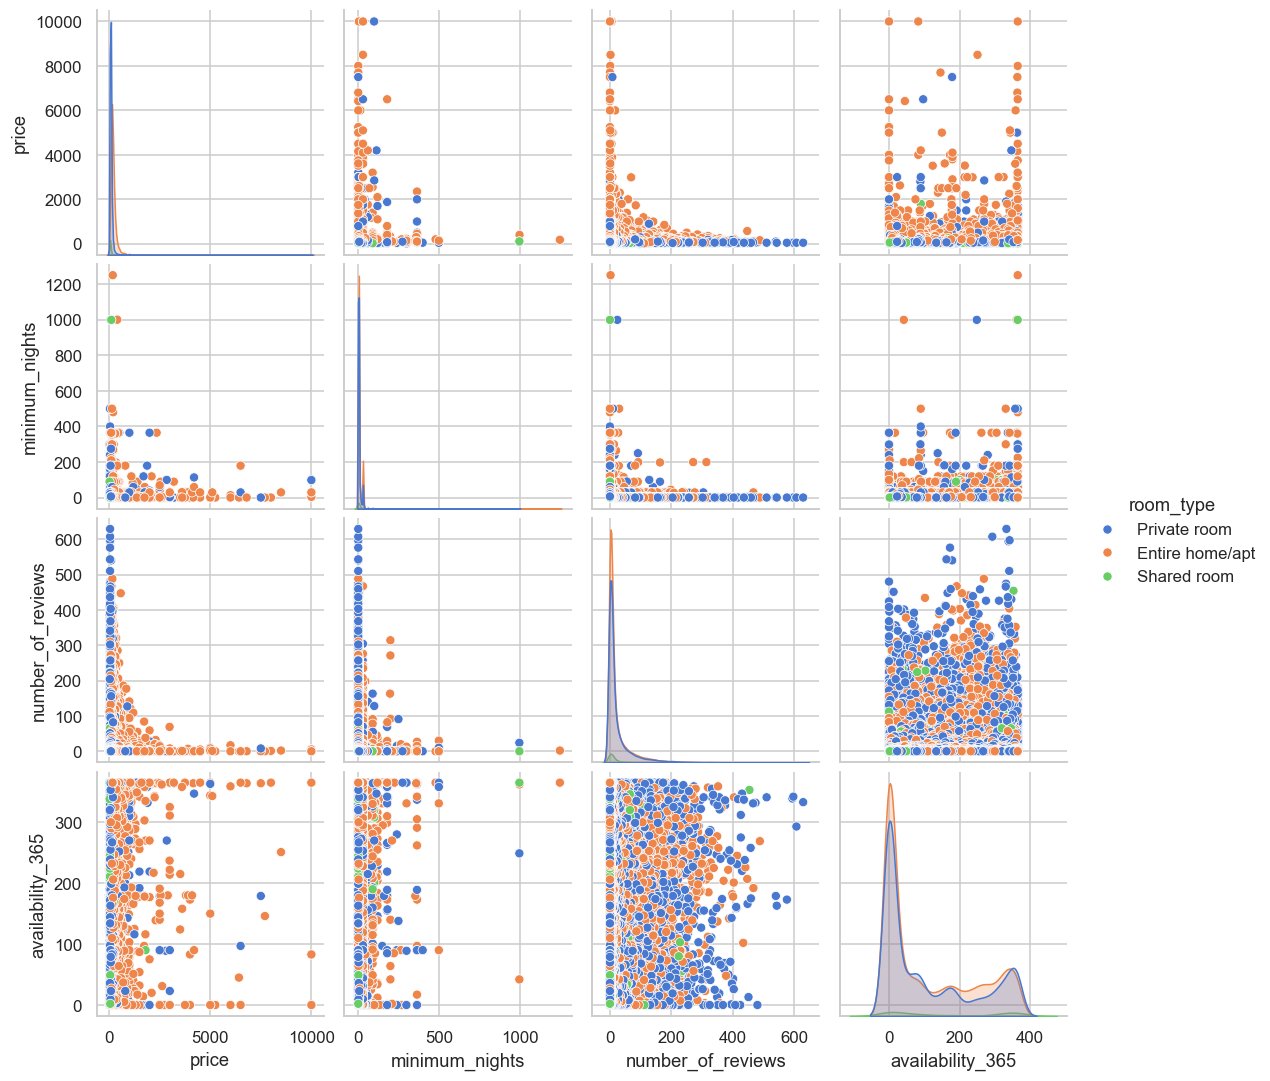

In [17]:
# Your code here
subset = df[['price','minimum_nights','number_of_reviews','availability_365','room_type']]

sns.pairplot(subset, hue='room_type')
plt.show()

**✍️ Your Interpretation:**  
*(Write here)*


---

# 📋 PART 6 — Final Investor Brief
### (10 Marks)

Synthesise your findings into a **short written brief** (Markdown only — no new code needed).

Your audience is **non-technical investors**. Write 250–350 words covering:

1. **Data Quality Warning:** What issues did you find that an investor must know before trusting any numbers?
2. **Manhattan Investor:** Opportunities and risks based purely on your EDA.
3. **Brooklyn Investor:** Same question for Brooklyn.
4. **Undecided Investor:** If you had to recommend one borough and one room type
   for consistent rental income, what would it be and why?
5. **One thing you would investigate next** if given more time.

> ⚠️ *You will be graded on the quality of reasoning, not just whether code runs.
> A technically correct analysis with a weak interpretation earns fewer marks than a thoughtful one.*


**✍️ Your Investor Brief:**

---

### Data Quality Warnin*(
*(Price distribution is highly skewed with extreme outliers. Some listings also have unrealistic minimum night requirements, which suggests potential data noi)*.)*

### Manhattan Investor
*(Manhattan has the highest prices, especially for entire homes. It is suitable for premium investment but requires higher capital.)*

## rooklyn*(*( Investor
Brooklyn offers lower entry prices with strong listing demand. It may provide better ROI fomid-range)*)* investors.

### Recommendation for Undecided Investor
*(For new investors seeking balanced risk and return, Brooklyn neighbourhoods with high listing density but moderate prices appear most promising.)*

### What I Would Investigate Next
*(Next I would investigate how price is influenced by location, room type, and host behavior. Additionally, I would analyze availability patterns and review activity to better understand listing ptal trends)*
opul. align these

---


---

# 🌟 BONUS CHALLENGE — For Those Who Finish Early
### (Up to 10 extra marks)

Choose **one** of the following:

---

### Bonus A — The Power Host Hypothesis

Define power hosts as those with more than 5 listings.

- Do power hosts charge significantly different prices compared to single-listing hosts?
- Do they receive more or fewer reviews per month?
- Is there a borough where power hosts are unusually concentrated?

Build a mini-analysis with at least 3 visualisations and a 100-word written conclusion.

---

### Bonus B — Listing Name Text Analysis

The `name` column contains free-text titles written by hosts.

- What are the most common words in listing names overall? In each borough?
- Do listings with words like luxury, cozy, or spacious in their name charge more on average?
- Can you identify naming patterns that correlate with higher prices?

> 💡 *Hint: The `str` accessor in pandas lets you work with string columns directly.
> For word frequency, think about splitting sentences and counting individual words.*


In [3]:
# Bonus code here (optional)
#Bonus A
# Define power hosts
df['host_type'] = df['calculated_host_listings_count'].apply(
    lambda x: 'Power Host' if x > 5 else 'Single Host'
)

df['host_type'].value_counts()


host_type
Single Host    44099
Power Host      4796
Name: count, dtype: int64

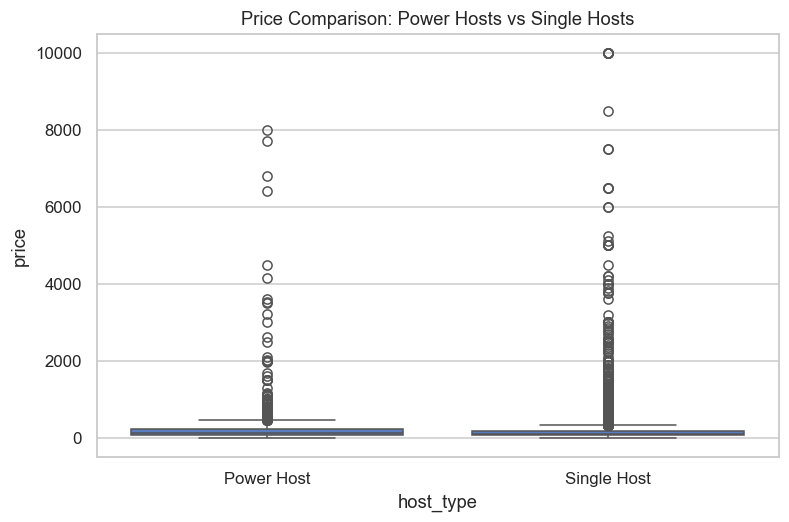

In [4]:
#Visualisation 1 — Price Comparison
plt.figure(figsize=(8,5))
sns.boxplot(x='host_type', y='price', data=df)
plt.title("Price Comparison: Power Hosts vs Single Hosts")
plt.show()

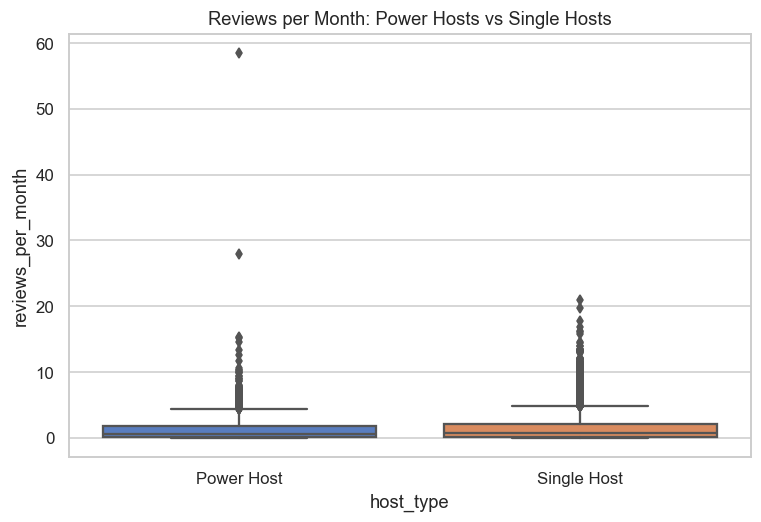

In [11]:
#Visualisation 2 — Reviews per Month
plt.figure(figsize=(8,5))
sns.boxplot(x='host_type', y='reviews_per_month', data=df)
plt.title("Reviews per Month: Power Hosts vs Single Hosts")
plt.show()

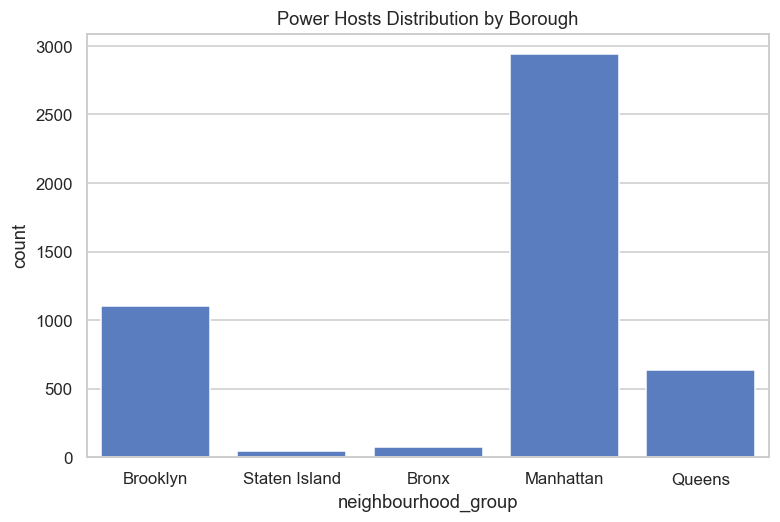

In [5]:
#Visualisation 3 — Borough Concentration
power_hosts = df[df['host_type'] == 'Power Host']

plt.figure(figsize=(8,5))
sns.countplot(x='neighbourhood_group', data=power_hosts)
plt.title("Power Hosts Distribution by Borough")
plt.show()

In [6]:
df.groupby('host_type')[['price','reviews_per_month']].mean()

,price,reviews_per_month
host_type,,
Power Host,180.879900,1.295252
Single Host,149.658224,1.380264


**✍️ Bonus Interpretation:**  
*(Bonus A:
The analysis compares power hosts (those with more than five listings) with single-listing hosts. The price comparison shows that power hosts tend to charge slightly higher prices, though the difference is not extremely large. When examining reviews per month, power hosts generally receive fewer reviews per listing, possibly because they manage many properties and demand is distributed among them. The borough analysis reveals that power hosts are highly concentrated in Manhattan and Brooklyn, which are the most popular tourist areas. Overall, the findings suggest that large-scale hosts focus on high-demand locations and operate multiple listings rather than relying on high review frequency per property.)*


name
in           16733
room          9389
bedroom       7231
private       6985
apartment     6113
cozy          4634
the           3869
to            3827
studio        3772
brooklyn      3629
apt           3571
spacious      3387
1             3357
with          3092
2             3079
of            2993
east          2967
and           2869
manhattan     2855
&             2820
Name: count, dtype: int64


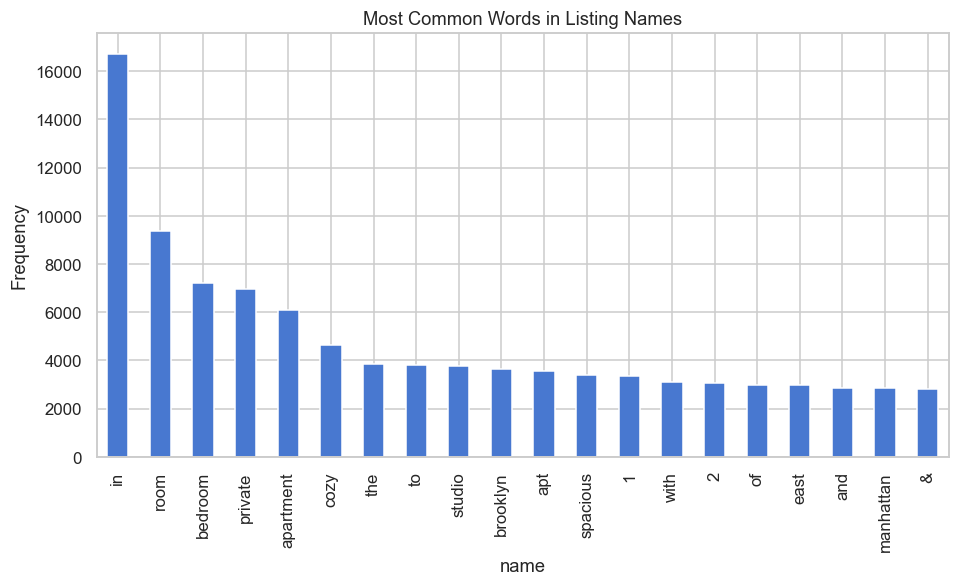

In [7]:
#Bonus B
# Convert to lowercase
names = df['name'].dropna().str.lower()

# Split words
words = names.str.split()

# Flatten list
all_words = words.explode()

# Count frequency
word_counts = all_words.value_counts().head(20)

print(word_counts)

plt.figure(figsize=(10,5))
word_counts.plot(kind='bar')
plt.title("Most Common Words in Listing Names")
plt.ylabel("Frequency")
plt.show()

In [16]:
#Most Common Words in Each Borough
borough_words = {}

for borough in df['neighbourhood_group'].unique():
    
    names = df[df['neighbourhood_group'] == borough]['name'].dropna().str.lower()
    
    words = names.str.split().explode()
    
    borough_words[borough] = words.value_counts().head(10)

for borough, counts in borough_words.items():
    print("\nTop words in", borough)
    print(counts)


Top words in Brooklyn
name
in              7873
room            4440
brooklyn        3606
private         3191
bedroom         3015
apartment       2564
williamsburg    2289
cozy            1843
spacious        1579
with            1508
Name: count, dtype: int64

Top words in Manhattan
name
in           7154
bedroom      3305
room         3295
apartment    2826
east         2758
private      2576
studio       2479
the          2117
village      2044
cozy         1918
Name: count, dtype: int64

Top words in Queens
name
in           1433
room         1347
to           1167
private       949
bedroom       761
cozy          715
apartment     563
manhattan     518
from          497
astoria       473
Name: count, dtype: int64

Top words in Staten Island
name
to           73
private      72
room         69
in           63
cozy         45
staten       43
ferry        41
nyc          41
home         40
apartment    36
Name: count, dtype: int64

Top words in Bronx
name
room         238
in      

{'luxury': luxury
False    148.392585
True     271.572177
Name: price, dtype: float64, 'cozy': cozy
False    158.319820
True     104.755038
Name: price, dtype: float64, 'spacious': spacious
False    153.850338
True     139.315000
Name: price, dtype: float64}


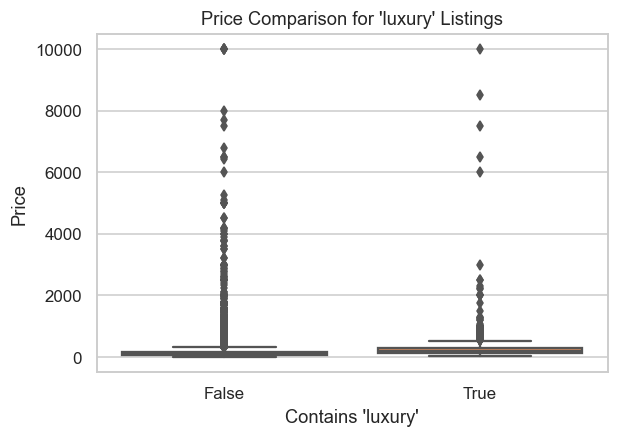

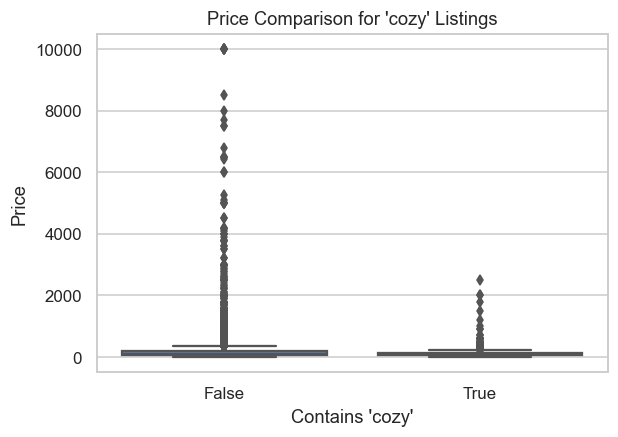

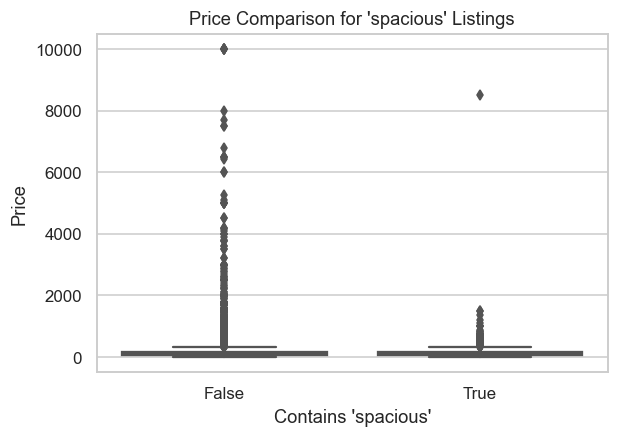

In [18]:
#Do “Luxury / Cozy / Spacious” Listings Charge More?
keywords = ['luxury','cozy','spacious']

for word in keywords:
    df[word] = df['name'].str.lower().str.contains(word, na=False)

price_analysis = {}

for word in keywords:
    price_analysis[word] = df.groupby(word)['price'].mean()

print(price_analysis)

for word in keywords:
    
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[word], y=df['price'])
    
    plt.title(f"Price Comparison for '{word}' Listings")
    plt.xlabel(f"Contains '{word}'")
    plt.ylabel("Price")
    
    plt.show()

In [19]:
#Naming Patterns Linked to Higher Prices
top_price_words = df.assign(
    word=df['name'].str.lower().str.split()
).explode('word')

avg_price_words = top_price_words.groupby('word')['price'].mean()

print(avg_price_words.sort_values(ascending=False).head(15))

word
-stunning            10000.0
flat-tribeca/soho     8500.0
70'                   7500.0
motoryacht            7500.0
kitchens              6500.0
(gramacy              5100.0
manhattans            5048.0
50p                   5000.0
11211                 5000.0
4-floor               5000.0
cap.                  5000.0
nearwilliamsburg      5000.0
#10299b               5000.0
exhibitions,          4160.0
bar/event/filming     4000.0
Name: price, dtype: float64


**✍️ Bonus Interpretation:**  
*(Bonus B:
The text analysis of listing names reveals common marketing patterns used by hosts. Words such as “room”, “private”, and “apartment” appear most frequently across all listings. Borough-level analysis shows slight variations in language, with Manhattan listings often emphasizing premium terms like “luxury” or “view,” while Brooklyn listings frequently include words such as “cozy” or “loft.” Listings containing words like “luxury” or “spacious” tend to have higher average prices compared to listings without these terms. This suggests that hosts use descriptive and aspirational language to signal higher-quality properties and attract guests willing to pay premium prices.)*


---

## 📊 Marking Rubric

| Part | Description | Marks |
|------|-------------|-------|
| Part 1 | First Contact (Inspection, Nulls, Duplicates) | 15 |
| Part 2 | Price Analysis | 25 |
| Part 3 | Host Behaviour & Market Structure | 20 |
| Part 4 | Geographic Deep Dive | 20 |
| Part 5 | Correlation & Multivariate | 10 |
| Part 6 | Investor Brief (Written) | 10 |
| **Total** | | **100** |
| Bonus | Power Host or Text Analysis | +10 |

**Code quality counts.** Plots must have titles, axis labels, and legends where appropriate.  
All cells must run top-to-bottom without errors.

---
*Dataset: New York City Airbnb Open Data 2019 — sourced from Inside Airbnb via public GitHub mirror.*  
*This notebook is for educational purposes only.*
